In [2]:
import pandas as pd
import numpy as np
import ast
from pathlib import Path

cwd = Path.cwd()
CSV_PATH = cwd.parent.parent / "tests" / "parameter_grid_neural_net_tests_2000_epochs_80_models.csv"

In [3]:
df = pd.read_csv(CSV_PATH, low_memory=False)
df.head(5)

,trial_num,epochs,split_seed,trial_seed,total_parameters,hidden_layer_sizes,dropout_size,has_batch_normlization,train_MSE,test_MSE,train_RMSE,test_RMSE,train_r2_score,test_r2_score,train_y,train_model_y,test_y,test_model_y
0,1,2000,42,67,1387,[],0.0,False,0.047237,0.062151,0.217340,0.249301,0.3241,0.1825,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.1729961335659027, 0.35616421699523926, 1.30...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.7521854639053345, 0.06917431950569153, 0.28..."
1,2,2000,42,68,1387,[],0.0,False,0.071671,0.109294,0.267715,0.330597,-0.0255,-0.4377,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.22411203384399414, 0.39037251472473145, -2....","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.8468335270881653, 0.01750880479812622, 0.38..."
2,3,2000,42,69,1387,[],0.2,False,0.106923,0.127018,0.326991,0.356396,-0.5299,-0.6708,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.16658568382263184, 0.30871471762657166, 2.0...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.6585938930511475, 0.13607126474380493, 0.30..."
3,4,2000,42,70,1387,[],0.2,False,0.091707,0.117338,0.302832,0.342546,-0.3122,-0.5435,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.14748737215995789, 0.31124329566955566, 2.0...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.6451665163040161, 0.13360396027565002, 0.35..."
4,5,2000,42,71,1387,[],0.0,True,0.021525,0.024484,0.146713,0.156473,0.6920,0.6779,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.18826504051685333, 0.3705768287181854, -0.0...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.7985051870346069, 0.05588313937187195, 0.30..."


In [4]:
def string_to_float_array(s):
    return np.array(ast.literal_eval(s), dtype=float)

In [5]:
df["train_y"] = df["train_y"].apply(string_to_float_array)
df["train_model_y"] = df["train_model_y"].apply(string_to_float_array)
df["test_y"] = df["test_y"].apply(string_to_float_array)
df["test_model_y"] = df["test_model_y"].apply(string_to_float_array)

In [6]:
df["arch"] = tuple(df["hidden_layer_sizes"])

In [7]:
score_col = "test_r2_score"

In [8]:
def best_per_architecture(df_subset, score_col):
    return (
        df_subset
        .sort_values(score_col, ascending=False)
        .groupby("hidden_layer_sizes", as_index=False)
        .head(1)
        .sort_values("total_parameters")
        .reset_index(drop=True)
    )

In [9]:
best_bn0_drop0 = best_per_architecture(
    df[(df["dropout_size"] == 0.0) & (df["has_batch_normlization"] == False)],
    score_col
)

best_bn0_drop02 = best_per_architecture(
    df[(df["dropout_size"] == 0.2) & (df["has_batch_normlization"] == False)],
    score_col
)

best_bn1_drop0 = best_per_architecture(
    df[(df["dropout_size"] == 0.0) & (df["has_batch_normlization"] == True)],
    score_col
)

best_bn1_drop02 = best_per_architecture(
    df[(df["dropout_size"] == 0.2) & (df["has_batch_normlization"] == True)],
    score_col
)

In [10]:
print(
    len(best_bn0_drop0),
    len(best_bn0_drop02),
    len(best_bn1_drop0),
    len(best_bn1_drop02),
)

10 10 10 10


In [11]:
best_bn0_drop0["order"]  = 0
best_bn0_drop02["order"] = 1
best_bn1_drop0["order"]  = 2
best_bn1_drop02["order"] = 3

In [12]:
merged_df = pd.concat(
    [
        best_bn0_drop0,
        best_bn0_drop02,
        best_bn1_drop0,
        best_bn1_drop02,
    ],
    ignore_index=True
)

In [13]:
arch_min_params = merged_df.groupby("arch")["total_parameters"].transform("min")
merged_df["arch_rank"] = arch_min_params

In [14]:
merged_df = (
    merged_df
    .sort_values(["arch_rank", "arch", "order"])
    .reset_index(drop=True)
)

In [15]:
merged_df

,trial_num,epochs,split_seed,trial_seed,total_parameters,hidden_layer_sizes,dropout_size,has_batch_normlization,train_MSE,test_MSE,...,test_RMSE,train_r2_score,test_r2_score,train_y,train_model_y,test_y,test_model_y,arch,order,arch_rank
0,1,2000,42,67,1387,[],0.0,False,0.047237,0.062151,...,0.249301,0.3241,0.1825,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.1729961335659027, 0.35616421699523926, 1.30...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.7521854639053345, 0.06917431950569153, 0.28...",[],0,1387
1,4,2000,42,70,1387,[],0.2,False,0.091707,0.117338,...,0.342546,-0.3122,-0.5435,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.14748737215995789, 0.31124329566955566, 2.0...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.6451665163040161, 0.13360396027565002, 0.35...",[],1,1387
2,5,2000,42,71,1387,[],0.0,True,0.021525,0.024484,...,0.156473,0.6920,0.6779,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.18826504051685333, 0.3705768287181854, -0.0...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.7985051870346069, 0.05588313937187195, 0.30...",[],2,1387
3,7,2000,42,73,1387,[],0.2,True,0.036160,0.040902,...,0.202241,0.4826,0.4620,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.1783362179994583, 0.31373968720436096, 0.64...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.6815897226333618, 0.12013210356235504, 0.35...",[],3,1387
4,9,2000,42,134,2791,"[2, 4]",0.0,False,0.003754,0.003908,...,0.062512,0.9463,0.9486,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.26729440689086914, 0.32664167881011963, 0.0...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.8609610795974731, 0.03930842876434326, 0.24...","[2, 4]",0,2791
5,12,2000,42,137,2791,"[2, 4]",0.2,False,0.014045,0.015620,...,0.124981,0.7990,0.7945,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.19343411922454834, 0.307208389043808, 0.064...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.7631573677062988, 0.10618060827255249, 0.28...","[2, 4]",1,2791
6,13,2000,42,138,2803,"[2, 4]",0.0,True,0.008996,0.009664,...,0.098304,0.8713,0.8729,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.274928480386734, 0.3163383901119232, -0.000...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.7951405048370361, 0.09148619323968887, 0.19...","[2, 4]",2,2791
7,16,2000,42,141,2803,"[2, 4]",0.2,True,0.046491,0.051435,...,0.226792,0.3348,0.3234,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.21851836144924164, 0.29144883155822754, 0.0...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.3130224347114563, 0.0864534080028534, 0.213...","[2, 4]",3,2791
8,18,2000,42,202,2867,"[2, 4, 8, 4]",0.0,False,0.017664,0.018763,...,0.136977,0.7473,0.7532,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.2696501314640045, 0.2998465299606323, 0.000...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.7697807550430298, 0.03906603157520294, 0.25...","[2, 4, 8, 4]",0,2867
9,20,2000,42,204,2867,"[2, 4, 8, 4]",0.2,False,0.003713,0.003893,...,0.062395,0.9469,0.9488,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.1997336447238922, 0.2770794928073883, 0.069...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.743956446647644, 0.06987185031175613, 0.261...","[2, 4, 8, 4]",1,2867


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
def plot_scatter_with_fit(ax, x, y):
    # Scatter
    ax.scatter(x, y, s=10, alpha=0.6)

    # Regression line (least squares)
    m, b = np.polyfit(x, y, 1)
    xx = np.linspace(x.min(), x.max(), 200)
    ax.plot(xx, m*xx + b, color="red", linestyle="--", linewidth=2, label=f"fit: y={m:.2f}x+{b:.2f}")

    # y = x reference line
    ax.plot(xx, xx, color="black", linewidth=1, alpha=0.6, label="ideal: y=x")

    ax.legend()

In [17]:
def plot_related(df):
    fig, axes = plt.subplots(len(df), 2, figsize=(15, 4*len(df)))
    axes = np.atleast_2d(axes)
    
    for i, row in df.reset_index(drop=True).iterrows():
        x_tr = np.asarray(row["train_y"], dtype=float)
        y_tr = np.asarray(row["train_model_y"], dtype=float)
        x_te = np.asarray(row["test_y"], dtype=float)
        y_te = np.asarray(row["test_model_y"], dtype=float)
    
        plot_scatter_with_fit(axes[i, 0], x_tr, y_tr)
        axes[i, 0].set_title(f'Parameters: {row["arch"]} = {row["total_parameters"]} - Dropout: {row["dropout_size"]} - Batch Norm: {"True" if row["has_batch_normlization"] else "False"} (trial {row["trial_num"]})')
        axes[i, 0].set_xlabel(r"Train y ($\mu$m)")
        axes[i, 0].set_ylabel(r"Model Train y ($\mu$m)")
    
        plot_scatter_with_fit(axes[i, 1], x_te, y_te)
        axes[i, 1].set_title(f'Parameters: {row["arch"]} = {row["total_parameters"]} - Dropout: {row["dropout_size"]} - Batch Norm: {"True" if row["has_batch_normlization"] else "False"} (trial {row["trial_num"]})')
        axes[i, 1].set_xlabel(r"Test y ($\mu$m)")
        axes[i, 1].set_ylabel(r"Model Test y ($\mu$m)")
    
    plt.tight_layout()
    plt.show()

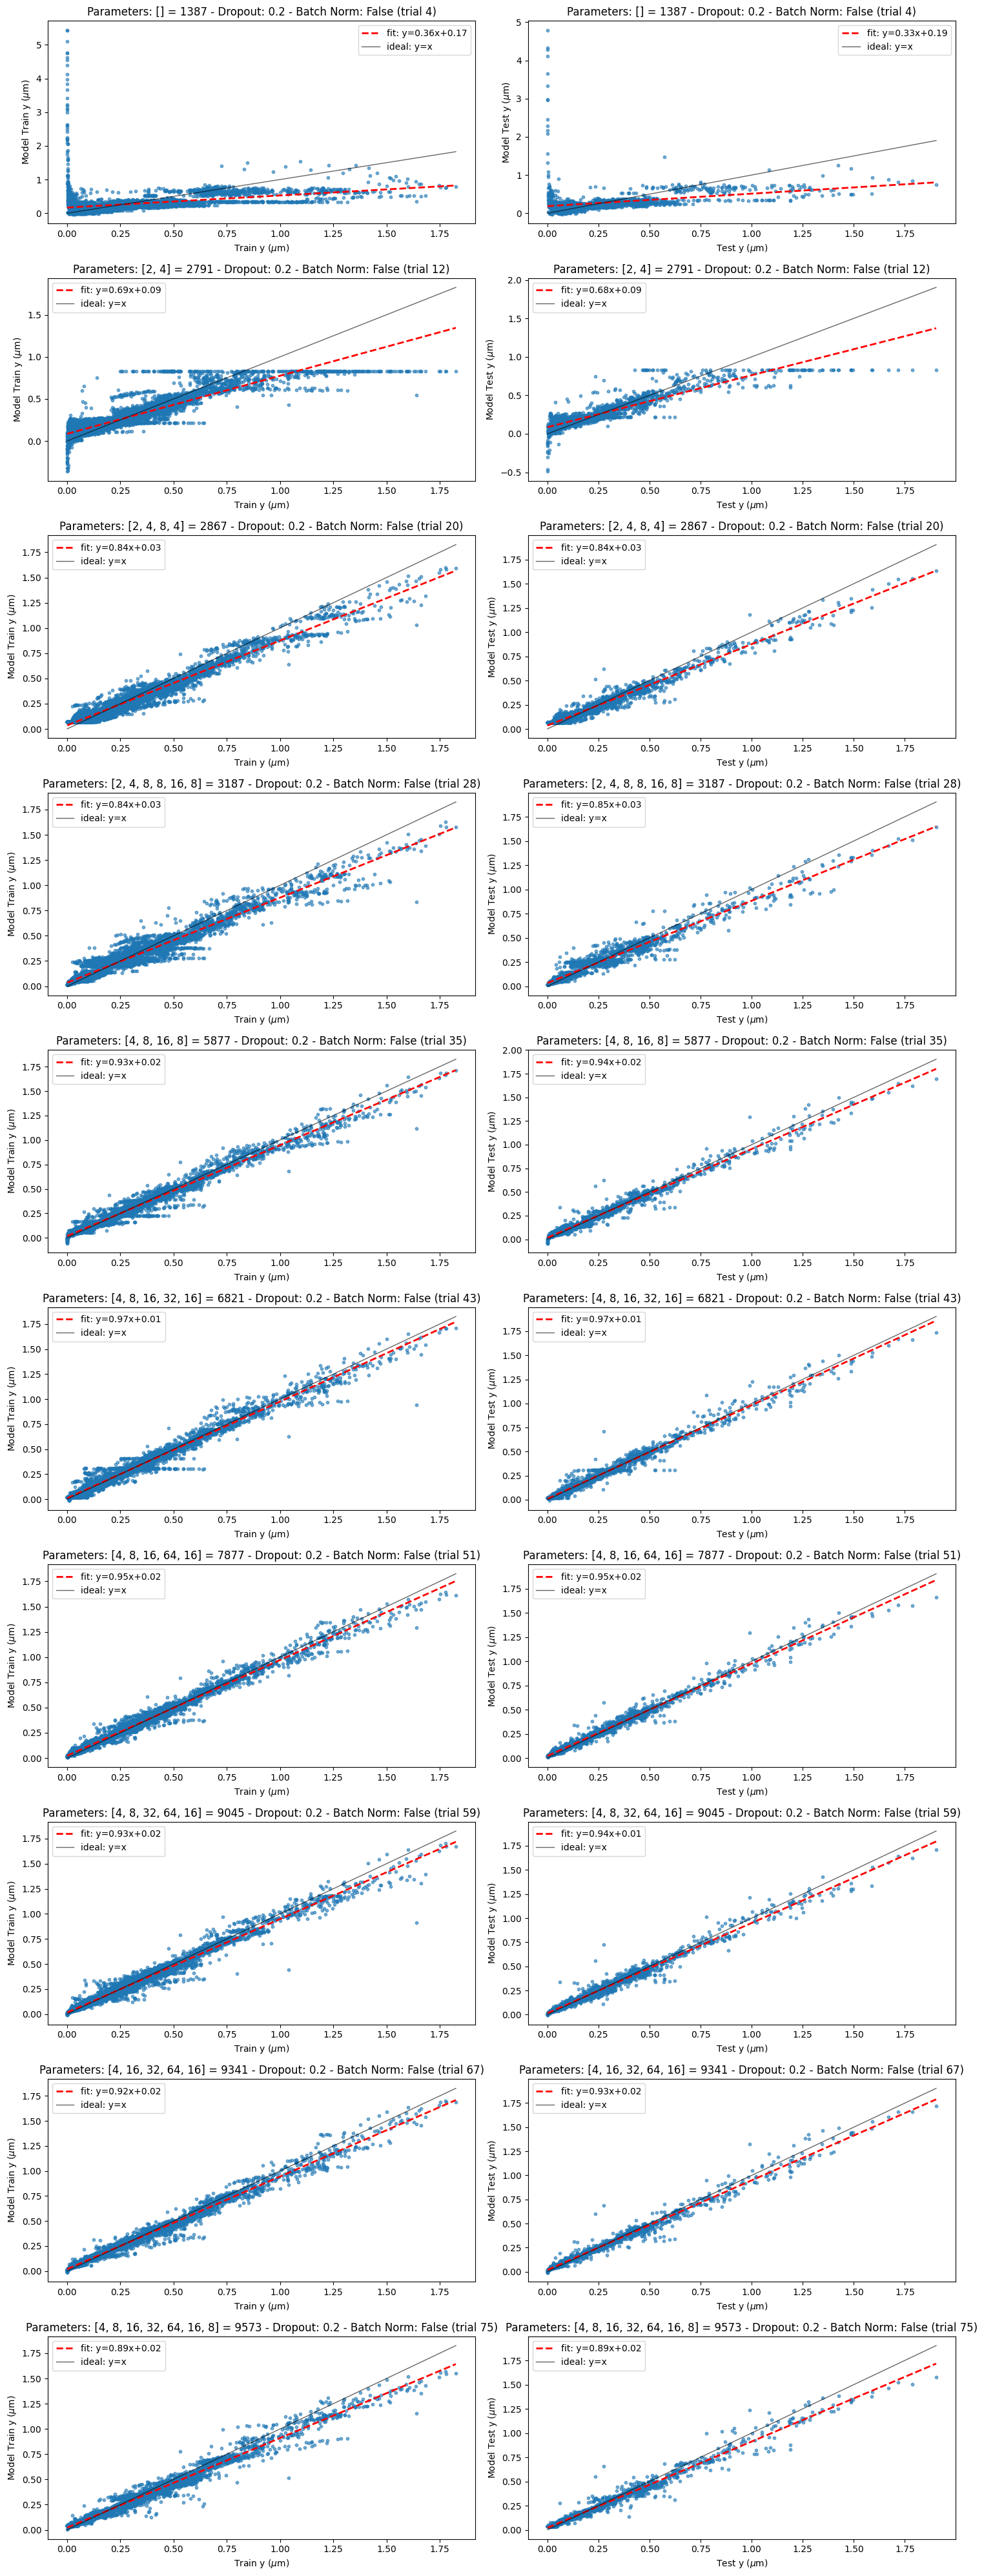

In [20]:
# plot_related(best_bn0_drop0) # No batch norm or dropout
plot_related(best_bn0_drop02) # No batch norm, 20% dropout
# plot_related(best_bn1_drop0) # Batch norm, no dropout
# plot_related(best_bn1_drop02) # Batch norm, 20% dropout